In [1]:
import numpy as np
import time
import timeit
from pathlib import Path
import os
import sys
current_dir = os.getcwd()
folder_b_path = os.path.abspath(os.path.join(current_dir, "../Raw_python_"))

if folder_b_path not in sys.path:
    sys.path.append(folder_b_path)

from MNIST_import import MnistDataloader

import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import seaborn as sns
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.utils import shuffle


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1


**Import Data**

In [2]:
training_images_filepath = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-images-idx3-ubyte\train-images-idx3-ubyte"
training_labels_filepath = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-labels-idx1-ubyte\train-labels-idx1-ubyte"
test_labels_filepath     = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-labels-idx1-ubyte\t10k-labels-idx1-ubyte" 
test_images_filepath     = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-images-idx3-ubyte\t10k-images-idx3-ubyte"
dataloader = MnistDataloader(
    training_images_filepath,
    training_labels_filepath,
    test_images_filepath,
    test_labels_filepath,
)
(x_train, y_train), (x_test, y_test) = dataloader.load_data()
x_train = x_train.reshape(len(x_train), -1) / 255.0
x_test = x_test.reshape(len(x_test), -1) / 255.0
x_train = np.hstack([x_train, np.ones((len(x_train), 1))])
x_test  = np.hstack([x_test,  np.ones((len(x_test), 1))]) # Taking the image arrays and appending 1s as the bias multiplication constant.
x_train, y_train = shuffle(x_train, y_train, random_state=42) # Shuffling training data, 42 seems to be a seed value that you want to keep consistent, but the actual math might be incredibly weird.
print(type(x_train))
print(np.shape(x_train))


<class 'numpy.ndarray'>
(60000, 785)


**Test Bench for various solution vector instantiation**
Part of the goal of this is to gain a benchmark understanding of which methods perform better. Obviously this will vary with the calculation and memory structure, but it's gaining intuition

In [9]:
"""
def instantiate_solution_vectors():
    d = []
    for i in range(len(y_train)):
        c = ([0]*10)
        c[y_train[i]] = 1
        d.append(c)
    #print("Length of d (number of solutions):", len(d), "Ex: Solution:" + str(d[3]) + ". Compare solution to y_train[3]: " + str(y_train[3]))    


def instantiate_solution_vectors():
    d = np.zeros((len(y_train), output_layer_size))
    for i in range(len(y_train)):
        d[y_train[i]] = 1

def instantiate_solution_vectors():
    y_train_t = torch.as_tensor(y_train, dtype=torch.long)
    d = torch.nn.functional.one_hot(y_train_t, num_classes=10)

"""
def instantiate_solution_vectors(train_sol=y_train):
    return np.eye(10)[train_sol]

execution_time = timeit.timeit(instantiate_solution_vectors, number=1000)
print(f"Total time for 1,000 runs: {execution_time:.6f} seconds")

Total time for 1,000 runs: 2.084445 seconds


1. Raw Python: Total time for 1,000 runs: 17.713203 seconds \
2. np zeros: Total time for 1,000 runs: 39.560270 seconds \
3. torch.nn: Total time for 1,000 runs: 7.439097 seconds \
4. np.eye: Total time for 1,000 runs: 2.236152 seconds. _numpy_ is fastest

Confirm Solution Vector properties

In [10]:
d = instantiate_solution_vectors()
print("shape: " + str(np.shape(d)))
print("datatype: " + str(type(d)))
print(len(d[0]))

shape: (60000, 10)
datatype: <class 'numpy.ndarray'>
10


**Gemini generated benchmark for dot products**

In [11]:
import timeit
import numpy as np
import torch

# 1. Pre-generate identical NumPy arrays (100,000 elements)
size = 100_000
np_v1 = np.arange(size, dtype=np.float32)
np_v2 = np.arange(size, dtype=np.float32)

# Pre-converted tensors for the pure PyTorch baseline
torch_v1 = torch.from_numpy(np_v1)
torch_v2 = torch.from_numpy(np_v2)

# 2. Define the three test scenarios
def pure_numpy():
    return np.dot(np_v1, np_v2)

def pure_torch():
    return torch.dot(torch_v1, torch_v2)

def convert_then_torch():
    # Convert on the fly, then dot product
    t1 = torch.from_numpy(np_v1)
    t2 = torch.from_numpy(np_v2)
    return torch.dot(t1, t2)

# 3. Execute the benchmark 10,000 times
iterations = 100_000
t_np    = timeit.timeit(pure_numpy, number=iterations)
t_torch = timeit.timeit(pure_torch, number=iterations)
t_conv  = timeit.timeit(convert_then_torch, number=iterations)

print(f"--- Benchmark Results ({iterations:,} runs) ---")
print(f"1. Pure NumPy:              {t_np:.5f} seconds")
print(f"2. Pure PyTorch:            {t_torch:.5f} seconds")
print(f"3. Conversion + PyTorch:    {t_conv:.5f} seconds")


--- Benchmark Results (100,000 runs) ---
1. Pure NumPy:              1.11772 seconds
2. Pure PyTorch:            1.20322 seconds
3. Conversion + PyTorch:    1.56022 seconds


For now, I'm going to continue on using numpy, and do a separate script evaluating pytorch. This script evaluates how the accuracy increases as the number of training epochs increases, but also, how shuffling the images, and re-generating random weights also creates a standard deviation of the reproducibility of these results.

In [12]:
# Initialize size of first hidden layer of the neural network
layer_1_size = len(x_train[0])  # Size of the first hidden layer is equal to the number of pixels in the input image + an extra weight for a bias term (28x28 + 1 = 785)
output_layer_size = 10
numLayers = 1 # Number of connecting layers from the input to output.

# Find a method for initializing the weights of the neural network. Bounds, based on Le Cun (1986) [-2.4/F, 2.4/F] or [-2.4/sqrt(F), 2.4/sqrt(F)]
layer_1_weight_range = 2.4 / np.sqrt(layer_1_size) # Le Cun (1986) weight initialization bounds
#weights = np.random.uniform(-layer_1_weight_range, layer_1_weight_range, size=(numLayers, output_layer_size, layer_1_size))  # Initialize weights for the first hidden layer
#print("Weights numpy shape: " + str(np.shape(weights)))

# Compute the number of dot product between the input and the weights of the first hidden layer for each neuron. Time this process to understand how scalable the neural network is.

# Pass each of the neuron dot products through the scaled hyperbolic tangent function to get the output of the first hidden layer.
# Time this process to understand how scalable the neural network is.

print("Layer 1 Size:", layer_1_size)

data_folder = Path(r"C:\Users\User\OneDrive\Desktop\ML_number_reader_1st_paper_tests\Beginning_ML_computerVision\MNIST_digit_reader_1st_attempt\python_\Data")
error_file_path = data_folder / "error_file.txt"
grad_C = np.zeros((output_layer_size, layer_1_size))  # Initialize the gradient of the cost function with respect to the weights of the first layer

alpha = 0.0001 # Learning rate
epochs = 40 # Number of iterations of SGD
iterations = 11
# Variables for the scaled hyperbolic tangent function
A = 1.7159
S = 2/3

# Create the error file if it does not exist
error_file_path.touch(exist_ok=True)
error_file_path.write_text("")   # reset before starting a new full training run

with open(error_file_path, "a") as file:
    print(range(iterations))
    for iter in range(iterations):
        weights = np.random.uniform(-layer_1_weight_range, layer_1_weight_range, size=(numLayers, output_layer_size, layer_1_size))  # Initialize weights for the first hidden layer
        x_train, y_train = shuffle(x_train, y_train, random_state=np.random.randint(0, 100))
        d = instantiate_solution_vectors(y_train)
        for z in range(epochs):
            start = time.time()
            for c in range(len(x_train)):
                input_vector = x_train[c]  # Convert the input image to a vector
                #print(np.shape(input_vector))
                #print(type(input_vector))
                # For each datapoint in the training set, compute the dot prdouct between the input image and the weights of the first hidden layer, 
                # and then pass the result through the scaled hyperbolic tangent function to get the output of the first hidden layer.
                net_input = weights[0] @ input_vector  # As it turns out, the output layer cell input ( a column vector ), is a dot product of the weight matrix rows. The column output is similar a matrix-vector multiplication then
                #print(type(net_input))
                #print("net_input shape: " + str(np.shape(net_input)))
                output_layer = A * np.tanh(S * net_input) # Compute the output of the first hidden layer for the first training image
                grad_C = np.outer(np.multiply((output_layer - d[c]), S * A * np.cosh(S * net_input)**-2), input_vector)
                #print("grad_C shape: " + str(np.shape(grad_C)))
                weights[0] = weights[0] - alpha * grad_C  # Update the weights of the input to output layer using the negative gradient of the cost function, with a prop. const. alpha (learning rate) to control the step size of the update.
            correct = 0
            for c in range(len(x_test)):
                input_vector = x_test[c]  # Convert the input image to a vector
                net_input = np.array([np.dot(input_vector, weights[0][j]) for j in range(output_layer_size)])
                output_layer = [A * np.tanh(S * net_input[j]) for j in range(output_layer_size)]  # Compute the output of the first hidden layer for the first training image
                output_key = output_layer.index(max(output_layer))
                if output_key == y_test[c]:
                    correct += 1
            accuracy = correct/len(x_test)
            file.write("Iteration " + str(iter) + ", Total Epochs: " + str(z) + "\n\n")  # Add a newline after each epoch
            file.write(str(accuracy) + "\n")   # Compute the error between the output of the first hidden layer and the expected output for the first training image
            # Compute the gradient of the cost function with respect to the weights of the first hidden layer ( This is a matrix )
            file.flush() # Save the file after each epoch to ensure that the data is not lost in case of a crash or interruption.
            print("Time for Epoch", z, ":", time.time() - start)

Layer 1 Size: 785
range(0, 11)
Time for Epoch 0 : 2.453416585922241
Time for Epoch 1 : 2.3783655166625977
Time for Epoch 2 : 2.4268643856048584
Time for Epoch 3 : 2.4017348289489746
Time for Epoch 4 : 2.422534942626953
Time for Epoch 5 : 2.373623847961426
Time for Epoch 6 : 2.5406389236450195
Time for Epoch 7 : 2.3946566581726074
Time for Epoch 8 : 2.4838955402374268
Time for Epoch 9 : 2.4632678031921387
Time for Epoch 10 : 2.406618118286133
Time for Epoch 11 : 2.462963819503784
Time for Epoch 12 : 2.498312473297119
Time for Epoch 13 : 2.4254274368286133
Time for Epoch 14 : 2.4471206665039062
Time for Epoch 15 : 2.4329349994659424
Time for Epoch 16 : 2.42510724067688
Time for Epoch 17 : 2.5041065216064453
Time for Epoch 18 : 2.4381048679351807
Time for Epoch 19 : 2.4620893001556396
Time for Epoch 20 : 2.5403566360473633
Time for Epoch 21 : 2.505239725112915
Time for Epoch 22 : 2.5313680171966553
Time for Epoch 23 : 2.558854341506958
Time for Epoch 24 : 2.5627880096435547
Time for Epoch

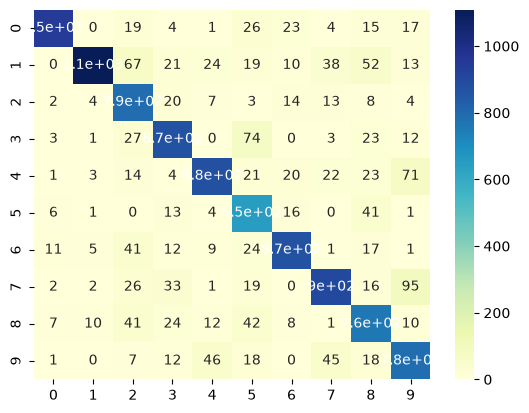

In [13]:
from tkinter import font


confusion_matrix = [[0 for _ in range(len(output_layer))] for _ in range(len(output_layer))]
correct = 0
for c in range(len(x_test)):
    input_vector = x_test[c]  # Convert the input image to a vector
    net_input = np.array([np.dot(input_vector, weights[0][j]) for j in range(output_layer_size)])
    output_layer = [A * np.tanh(S * net_input[j]) for j in range(output_layer_size)]  # Compute the output of the first hidden layer for the first training image
    output_key = output_layer.index(max(output_layer))
    if output_key == y_test[c]:
        confusion_matrix[y_test[c]][y_test[c]] += 1
        correct += 1
    else:
        confusion_matrix[output_key][y_test[c]] += 1

sns.heatmap(confusion_matrix, annot=True, cmap="YlGnBu", annot_kws={"size": 10})
error = correct/len(x_test)
plt.show()

In [14]:
print("Test Dataset Accuracy: " + str(error))

Test Dataset Accuracy: 0.8551
